In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates


In [2]:
#Reading
df : pd.DataFrame = pd.read_csv("..\\cleaning\\clean_data_grouped.csv")

### Data Preprocessing

In [3]:
df = df.drop(columns=["Unnamed: 21" , "city.1", "country.1"]) #Drop the unnecessary columns
df["posted_at"] = pd.to_datetime(df["posted_at"]) #Convert to datetime

## Analysis 1 - Number of Job Postings Per Company

In [32]:
def num_of_job_postings():
    # Companies eligible for hiring rate analysis
    df_clean = df[df["company_name"] != "Unknown"].copy()
    posting_counts = df_clean["company_name"].value_counts()
    eligible_companies_index = posting_counts[posting_counts >= 4].index
    
    postings_per_company = df_clean["company_name"].value_counts().reset_index()
    postings_per_company.columns = ["company_name", "posting_count"]

    top30 = postings_per_company.head(30)
    # Chart — Horizontal Bar (Top 30)
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(top30["company_name"][::-1], top30["posting_count"][::-1], color="steelblue")
    ax.set_xlabel("Number of Job Postings")
    ax.set_title("Top 30 Companies by Job Postings")

    for i, (val, name) in enumerate(zip(top30["posting_count"][::-1], top30["company_name"][::-1])):
        ax.text(val + 0.2, i, str(val), va="center")

    plt.tight_layout()
    plt.savefig(f"output\\{ax.get_title()}.png")
    plt.show()
    
    

In [21]:
# Companies eligible for hiring rate analysis
df_clean = df[df["company_name"] != "Unknown"].copy()
posting_counts = df_clean["company_name"].value_counts()
eligible_companies_index = posting_counts[posting_counts >= 4].index
# Expected: ~20–25 companies
print(f"Companies with 3+ postings: {len(eligible_companies_index)}")

Companies with 3+ postings: 21


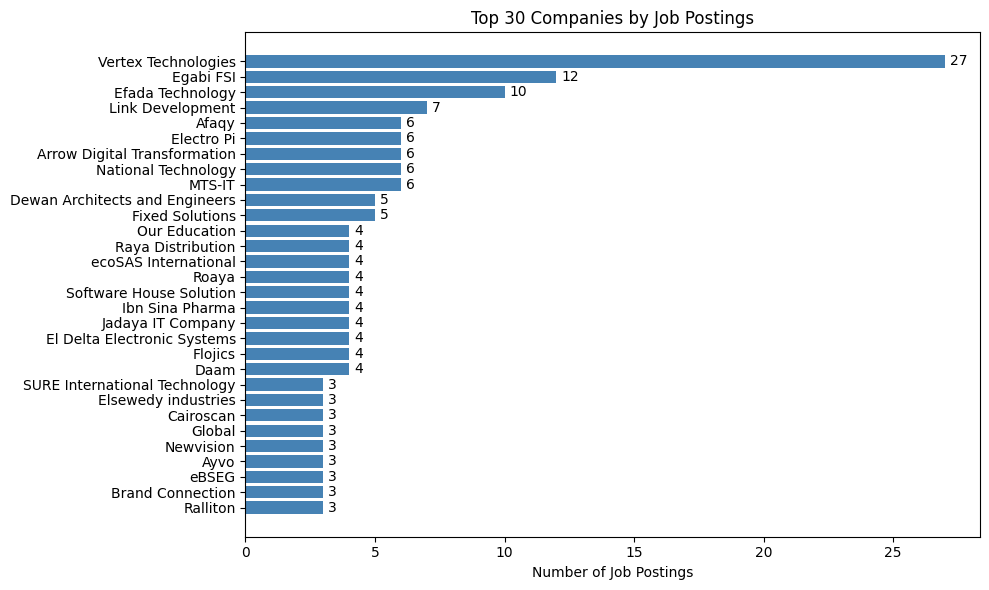

In [24]:
postings_per_company = df_clean["company_name"].value_counts().reset_index()
postings_per_company.columns = ["company_name", "posting_count"]

top30 = postings_per_company.head(30)
# Chart — Horizontal Bar (Top 30)
pythonfig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top30["company_name"][::-1], top30["posting_count"][::-1], color="steelblue")
ax.set_xlabel("Number of Job Postings")
ax.set_title("Top 30 Companies by Job Postings")

for i, (val, name) in enumerate(zip(top30["posting_count"][::-1], top30["company_name"][::-1])):
    ax.text(val + 0.2, i, str(val), va="center")

plt.tight_layout()
plt.savefig(f"output\\{ax.get_title()}.png")
plt.show()

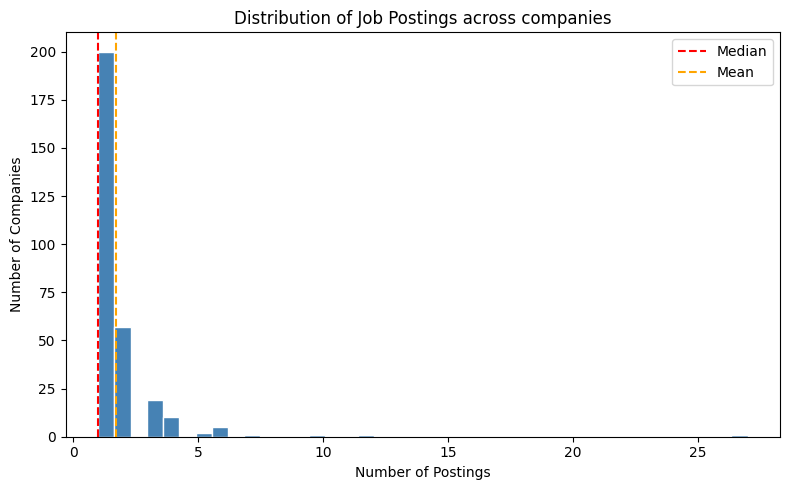

In [17]:
# Chart — Distribution Histogram

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(postings_per_company["posting_count"], bins=40, color="steelblue", edgecolor="white")
k = ax.set_xlabel("Number of Postings")
ax.set_ylabel("Number of Companies")
ax.set_title("Distribution of Job Postings across companies")
ax.axvline(postings_per_company["posting_count"].median(), color="red", linestyle="--", label="Median")
ax.axvline(postings_per_company["posting_count"].mean(), color="orange", linestyle="--", label="Mean")
ax.legend()

plt.tight_layout()
plt.savefig(f"output\\{ax.get_title()}.png")
plt.show()

## Analysis 2 - Hiring Rate (Avg Days Between Postings)

In [7]:
posting_counts = df_clean["company_name"].value_counts()
eligible = posting_counts[posting_counts >= 4].index

df_eligible = df_clean[df_clean["company_name"].isin(eligible)].copy()
df_eligible = df_eligible.sort_values(["company_name", "posted_at"])
df_eligible

,job_title,company_name,company_size,location,work_type,work_setting,career_level,education_level,skills_and_tools,posted_at,...,max_experience_years,salary_min,salary_max,salary_currency,salary_period,city,country,job_title_clean,job_seniority,job_title_group
272,Technical Support Engineer,Afaqy,101-500 employees,"Cairo, Egypt",['Full Time'],Hybrid,"['Junior', 'Mid-Level']",Not Specified,"['Application Support', 'JIRA', 'SaaS']",2026-02-10 20:10:00,...,4,NaN,NaN,NaN,NaN,Cairo,Egypt,application support engineer,"['Junior', 'Mid-Level']",Technical Support Engineer
243,Software Engineer,Afaqy,101-500 employees,"Cairo, Egypt",['Full Time'],Hybrid,"['Junior', 'Senior']",Bachelor's Degree,"['Java SE', 'Computer Science', 'Computer Engi...",2026-02-15 19:08:00,...,6,NaN,NaN,NaN,NaN,Cairo,Egypt,java developer,"['Junior', 'Senior']",Software Engineer
231,Technical Support Engineer,Afaqy,101-500 employees,"Cairo, Egypt",['Full Time'],Hybrid,"['Junior', 'Mid-Level']",Bachelor's Degree,"['Computer Hardware', 'Software', 'Technical S...",2026-02-19 17:30:00,...,4,NaN,NaN,NaN,NaN,Cairo,Egypt,technical support engineer,"['Junior', 'Mid-Level']",Technical Support Engineer
232,Frontend Developer,Afaqy,101-500 employees,"Cairo, Egypt",['Full Time'],Hybrid,"['Mid-Level', 'Senior']",Bachelor's Degree,"['Information Technology (IT)', 'Angular', 'Co...",2026-02-19 17:30:00,...,6,NaN,NaN,NaN,NaN,Cairo,Egypt,frontend developer,"['Mid-Level', 'Senior']",Frontend Developer
38,AI/ML Engineer,Afaqy,101-500 employees,"Cairo, Egypt",['Full Time'],Hybrid,"['Mid-Level', 'Senior']",Not Specified,"['AI', 'Python', 'Software Development', 'Mach...",2026-04-02 13:39:00,...,6,15000.0,70000.0,EGP,Month,Cairo,Egypt,ai developer midlevel,"['Mid-Level', 'Senior']",AI/ML Engineer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,QA Engineer,Vertex Technologies,11-50 employees,"Cairo, Egypt",['Full Time'],On-Site,"['Junior', 'Senior']",Bachelor's Degree,"['Test Automation', 'Selenium', 'Cypress', 'CI...",2026-04-09 12:57:00,...,6,NaN,NaN,NaN,NaN,Cairo,Egypt,middle automation qa engineer,"['Junior', 'Senior']",QA Engineer
123,Frontend Developer,ecoSAS International,51-100 employees,"Giza, Egypt",['Full Time'],On-Site,['Mid-Level'],Bachelor's Degree,"['Information Technology (IT)', 'PHP', 'Softwa...",2026-03-11 15:43:00,...,5,NaN,NaN,NaN,NaN,Giza,Egypt,frontend developer,['Mid-Level'],Frontend Developer
124,QA Engineer,ecoSAS International,51-100 employees,"Giza, Egypt",['Full Time'],On-Site,"['Junior', 'Mid-Level']",Bachelor's Degree,"['Information Technology (IT)', 'QA', 'Softwar...",2026-03-11 15:55:00,...,3,NaN,NaN,NaN,NaN,Giza,Egypt,software tester,"['Junior', 'Mid-Level']",QA Engineer
440,Full Stack Developer,ecoSAS International,51-100 employees,"Giza, Egypt",['Full Time'],On-Site,"['Mid-Level', 'Senior']",Bachelor's Degree,"['Information Technology (IT)', 'PHP', 'Softwa...",2026-03-12 15:25:00,...,7,NaN,NaN,NaN,NaN,Giza,Egypt,fullstack developer,"['Mid-Level', 'Senior']",Full Stack Developer


In [25]:

# Compute avg gap in days between consecutive postings per company
def avg_days_between_posts(group):
    gaps = group["posted_at"].diff().dt.days.dropna()
    return gaps.mean()

hiring_rate = (
    df_eligible.groupby("company_name")
    .apply(avg_days_between_posts)
    .reset_index()
)
hiring_rate.columns = ["company_name", "avg_days_between_posts"]
hiring_rate = hiring_rate.sort_values("avg_days_between_posts")

C:\Users\Dell\AppData\Local\Temp\ipykernel_12976\562226015.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(avg_days_between_posts)


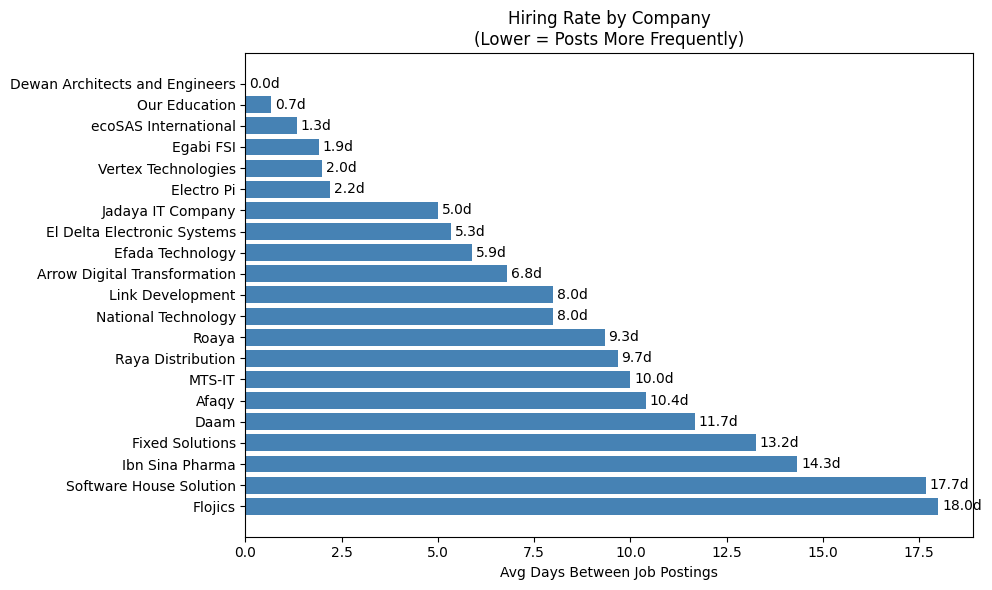

In [28]:
# Chart — Hiring Rate Bar Chart
pythonfig, ax = plt.subplots(figsize=(10, 6))

ax.barh(hiring_rate["company_name"][::-1], hiring_rate["avg_days_between_posts"][::-1], color="steelblue")
ax.set_xlabel("Avg Days Between Job Postings")
ax.set_title("Hiring Rate by Company\n(Lower = Posts More Frequently)")

for i, val in enumerate(hiring_rate["avg_days_between_posts"][::-1]):
    ax.text(val + 0.1, i, f"{val:.1f}d", va="center")

plt.tight_layout()
plt.savefig(f"output\\{ax.get_title()[:22]}.png")
plt.show()

A More clear chart that highlights number of job postings with the hiring rate

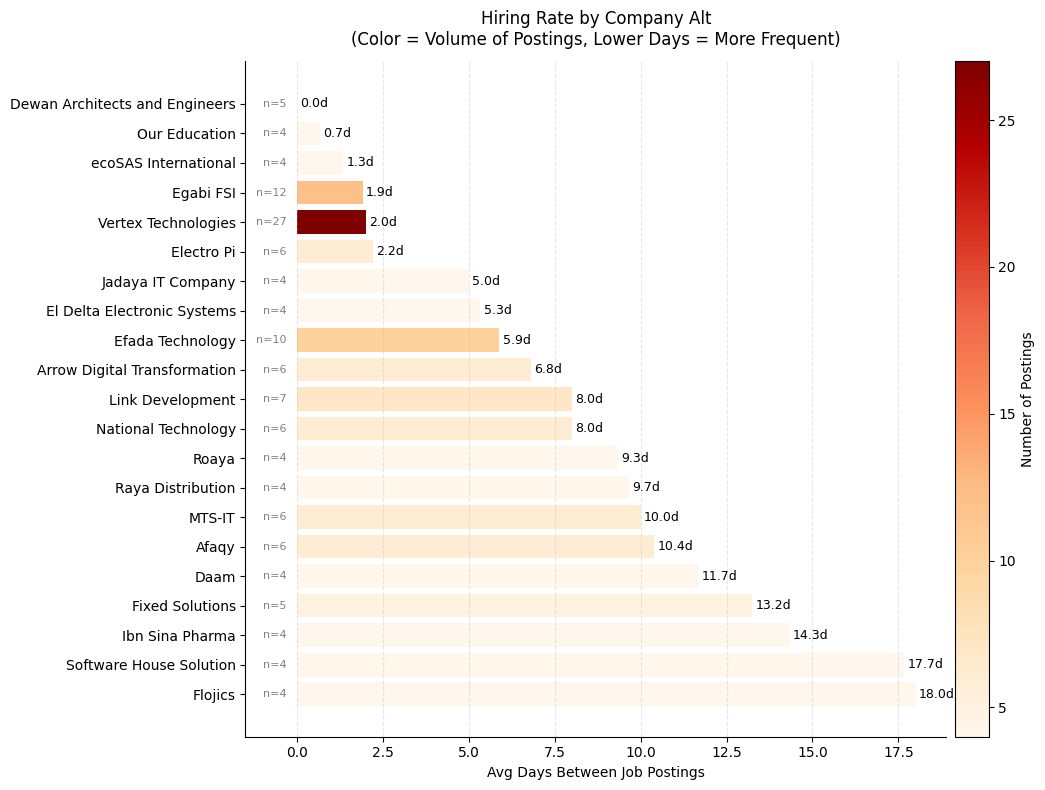

In [30]:
# ── Merge posting counts into hiring_rate ──────────────────────────────────
hiring_rate["posting_count"] = hiring_rate["company_name"].map(posting_counts)
hiring_rate = hiring_rate.sort_values("avg_days_between_posts")

hr = hiring_rate[::-1].reset_index(drop=True)  # flip for horizontal bar

# ── Color map based on posting count ──────────────────────────────────────
norm = plt.Normalize(vmin=hr["posting_count"].min(), vmax=hr["posting_count"].max())
cmap = mpl.colormaps['OrRd']
colors = cmap(norm(hr["posting_count"]))

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(hr["company_name"], hr["avg_days_between_posts"], color=colors)

# ── Annotations: days + posting count ─────────────────────────────────────
for i, (days, count) in enumerate(zip(hr["avg_days_between_posts"], hr["posting_count"])):
    ax.text(days + 0.1, i, f"{days:.1f}d", va="center", fontsize=9)
    ax.text(-0.3, i, f"n={count}", va="center", ha="right", fontsize=8,
            color="gray")

# ── Colorbar legend ────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Number of Postings", fontsize=10)

# ── Styling ────────────────────────────────────────────────────────────────
ax.set_xlabel("Avg Days Between Job Postings")
ax.set_title("Hiring Rate by Company Alt\n(Color = Volume of Postings, Lower Days = More Frequent)", pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(left=-1.5)  # make room for n= labels on the left
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(f"output\\{ax.get_title()[:26]}.png")
plt.show()

## Analysis 3 — Postings Over Time (Top 5 Companies)

In [11]:
top5 = postings_per_company.head(5)["company_name"].tolist()

df_top5 = df_clean[df_clean["company_name"].isin(top5)].copy()
df_top5["week"] = df_top5["posted_at"].dt.to_period("W").dt.start_time

timeline = (
    df_top5.groupby(["week", "company_name"])
    .size()
    .reset_index(name="postings")
)

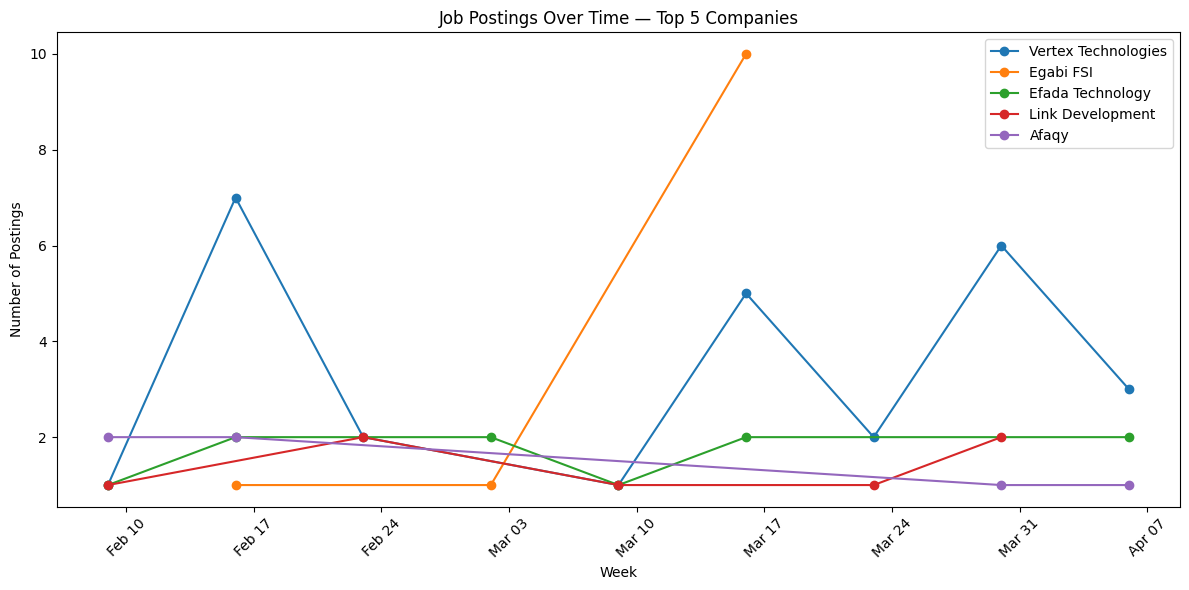

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

for company in top5:
    data = timeline[timeline["company_name"] == company]
    ax.plot(data["week"], data["postings"], marker="o", label=company)

ax.set_xlabel("Week")
ax.set_ylabel("Number of Postings")
ax.set_title("Job Postings Over Time — Top 5 Companies")
ax.legend()
plt.xticks(rotation=45)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

plt.tight_layout()
plt.savefig(f"output\\{ax.get_title()}.png")
plt.show()

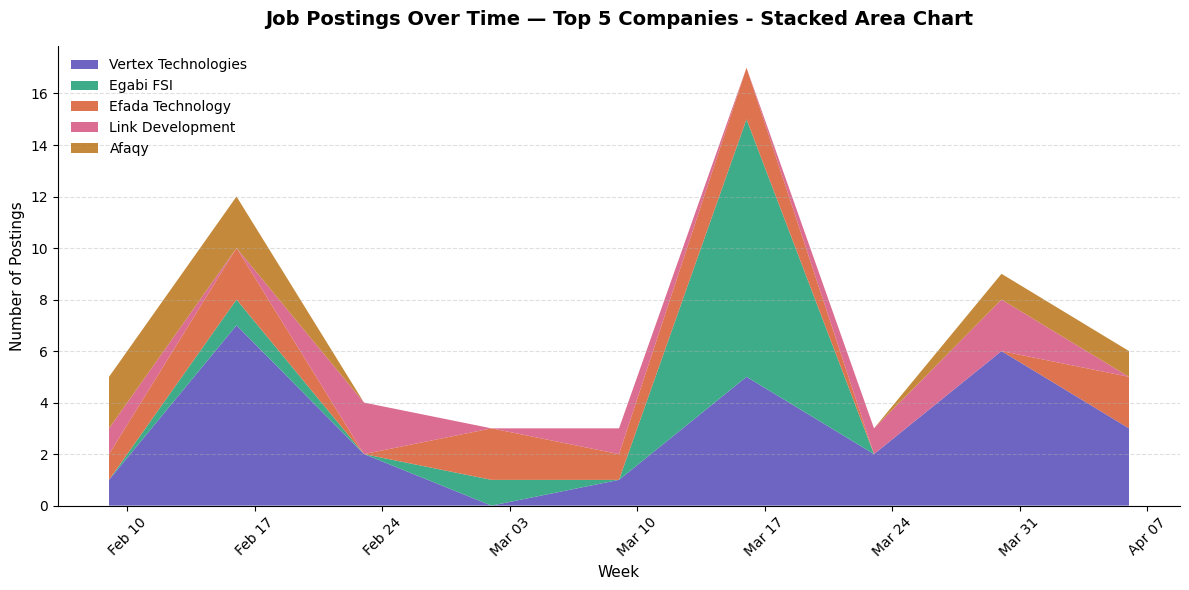

In [13]:
# Another chart showing job postings over time
top5 = postings_per_company.head(5)["company_name"].tolist()

df_top5 = df_clean[df_clean["company_name"].isin(top5)].copy()
df_top5["week"] = df_top5["posted_at"].dt.to_period("W").dt.start_time

timeline = (
    df_top5.groupby(["week", "company_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top5)  # keep consistent order
)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E", "#BA7517"]

ax.stackplot(
    timeline.index,
    [timeline[col] for col in timeline.columns],
    labels=timeline.columns,
    colors=colors,
    alpha=0.85
)

# ── Styling ──
ax.set_title("Job Postings Over Time — Top 5 Companies - Stacked Area Chart", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Week", fontsize=11)
ax.set_ylabel("Number of Postings", fontsize=11)

# ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.tick_params(axis="x", rotation=45)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.savefig(f"output\\{ax.get_title()}.png")
plt.show()

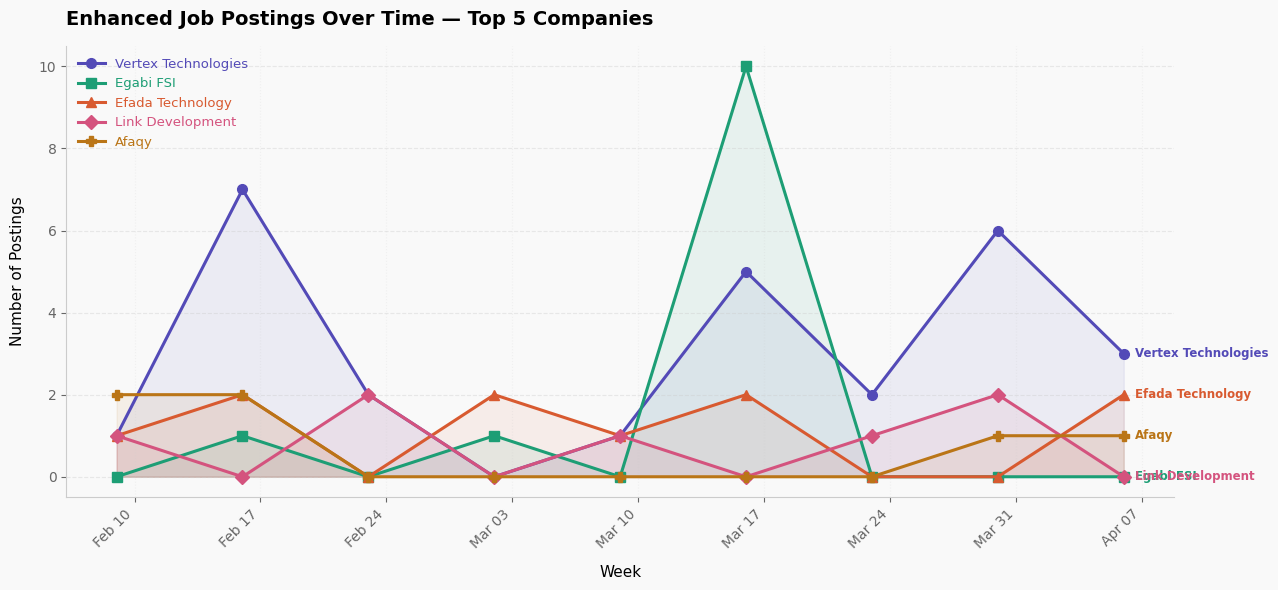

In [14]:
from matplotlib.ticker import MaxNLocator
# ── Style config ───────────────────────────────────────────────────────────
colors      = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E", "#BA7517"]
markers     = ["o", "s", "^", "D", "P"]
linestyles  = ["-", "-", "-", "-", "-"]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#F9F9F9")
ax.set_facecolor("#F9F9F9")

for col, color, marker in zip(timeline.columns, colors, markers):
    series = timeline[col]

    # Shaded area under each line
    ax.fill_between(series.index, series.values, alpha=0.08, color=color)

    # Main line
    ax.plot(series.index, series.values,
            color=color, marker=marker,
            linewidth=2.2, markersize=7,
            label=col, zorder=3)

    # Annotate the last point with the company name
    ax.annotate(
        col,
        xy=(series.index[-1], series.iloc[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        color=color,
        fontsize=8.5,
        va="center",
        fontweight="bold"
    )

# ── Styling ────────────────────────────────────────────────────────────────
ax.set_title("Enhanced Job Postings Over Time — Top 5 Companies",
             fontsize=14, fontweight="bold", pad=15, loc="left")
ax.set_xlabel("Week", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Postings", fontsize=11, labelpad=10)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=9.5,
    labelcolor="linecolor"  # matches each label color to its line
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45, ha="right")

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCCCC")
ax.tick_params(colors="#666666")

ax.grid(axis="y", linestyle="--", alpha=0.4, color="#CCCCCC")
ax.grid(axis="x", linestyle=":", alpha=0.2, color="#CCCCCC")

# Expand right margin so company name annotations don't get clipped
plt.subplots_adjust(right=0.78)

plt.tight_layout()
plt.savefig(f"output\\Enhanced Job Postings Over Time.png")
plt.show()